In [1]:
import argparse
import os

import pandas as pd
import pickle
from tqdm import tqdm
from copy import deepcopy

import numpy as np
import torch
from torch import optim
from torch.utils.tensorboard import SummaryWriter

import matplotlib.pyplot as plt

import sys

In [24]:
# top r svd
def top_r_svd(A, r):
    V, S, Vt = torch.linalg.svd(A, full_matrices=True)

    Vr = V[:, :r]  
    Sr = S[:r]   
    Vtr = Vt[:r, :]
    return Vr, Sr, Vtr

# norm by dividing the max singular value
def svd_norm(A):
    U, S, V = torch.svd(A)

    S_normalized = S / S.max()
    scale = S.max()

    A_normalized = U @ torch.diag(S_normalized) @ V.t()

    return A_normalized, scale

# norm by UV
def uv_norm(A):
    U, S, V = torch.svd(A)

    A_normalized = U @ V.t()

    return A_normalized

# reverse norm by multipying the max singular value
def svd_norm_reverse(A, scale):
    U, S, V = torch.svd(A)

    S_reverse = S * scale

    A_normalized = U @ torch.diag(S_reverse) @ V.t()

    return A_normalized

In [162]:
mat1 = torch.randn(100, 1)
mat2 = torch.randn(1, 3)
M = mat1 @ mat2

r = mat2.shape[0]
epochs = 5000
alpha = 0.1
p = 0.75
noise = 0.01
dataset = 'random'

print(mat2)

tensor([[-0.6819, -0.4484,  0.8109]])


/tmp/ipykernel_4075876/3992544675.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(MTM, requires_grad=True)


norm of M: 11.693020820617676


  0%|          | 0/5000 [00:00<?, ?it/s, In epoch 3, loss: 280471.968750)]

100%|██████████| 5000/5000 [00:16<00:00, 310.32it/s, In epoch 4999, loss: 0.067539)]   


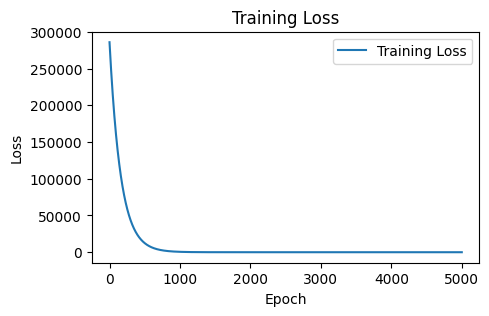

In [174]:
"""
Train for X
"""
# observed M & norm
mask = torch.bernoulli(torch.full((M.shape[0],), (1-p))).bool()
observed_M = deepcopy(M)
observed_M[mask] = 0 # mask user
#observed_M = M
#observed_M_norm, scale_M = svd_norm(observed_M) # svd norm
MTM = torch.mm(observed_M.t(), observed_M)
scale_diag = (p-1) / (p**2) * torch.diag(MTM).diag() # objective matrix
A = scale_diag + ((1/(p**2)) *MTM)

print(f"norm of M: {torch.norm(M)}")

# parameters setting
d1, d2 = observed_M.shape
#X = torch.randn(d2, d2, requires_grad=True)
X = torch.tensor(MTM, requires_grad=True)
loop = tqdm(range(epochs))
eta = 1 / np.sqrt(epochs)
optimizer = optim.SGD([X], lr=eta)

# opt
train_losses = []
writer = SummaryWriter('runs/'+dataset)
for i in loop:
    loss = ((X - A)**2).mean() # mse loss
    U, D, Vt = torch.linalg.svd(X, full_matrices=False)
    loss.backward()

    noise_matrix = torch.normal(mean=0, std=noise, size=(d2, d2))

    X.grad = X.grad + alpha * U @ Vt + noise_matrix # alg
    """
    with torch.no_grad():
        X.data += -eta*X.grad
    """
    optimizer.step()
    X.grad.zero_()
    #print(loss.item())
    writer.add_scalar('Loss', loss.item(), i)
    train_losses.append(loss.item())
    loop.set_postfix_str('In epoch {}, loss: {:.6f})'.format(i, loss.item()))

plt.figure(figsize=(5, 3))
plt.plot(train_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
plt.show()

X_stable = X

In [166]:
observed_M

tensor([[ 2.5929e-02,  1.7050e-02, -3.0832e-02],
        [ 4.1364e-01,  2.7200e-01, -4.9187e-01],
        [ 8.2278e-01,  5.4103e-01, -9.7839e-01],
        [-1.6805e-01, -1.1050e-01,  1.9983e-01],
        [ 1.5555e-01,  1.0229e-01, -1.8497e-01],
        [ 2.8506e-01,  1.8744e-01, -3.3897e-01],
        [-3.9813e-01, -2.6180e-01,  4.7343e-01],
        [-6.4966e-01, -4.2719e-01,  7.7252e-01],
        [-9.5156e-02, -6.2571e-02,  1.1315e-01],
        [ 1.3334e+00,  8.7677e-01, -1.5855e+00],
        [ 1.1163e-01,  7.3402e-02, -1.3274e-01],
        [-1.1348e+00, -7.4623e-01,  1.3495e+00],
        [ 1.8262e-01,  1.2009e-01, -2.1716e-01],
        [ 6.2154e-01,  4.0871e-01, -7.3909e-01],
        [-9.0759e-02, -5.9680e-02,  1.0792e-01],
        [-7.7006e-01, -5.0636e-01,  9.1569e-01],
        [-1.3165e+00, -8.6568e-01,  1.5655e+00],
        [ 1.1324e-01,  7.4461e-02, -1.3465e-01],
        [ 7.0414e-01,  4.6302e-01, -8.3731e-01],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00],
        [ 0.0000e+00

In [175]:
"""
normalization for result
"""
X = X_stable
norms = torch.norm(MTM, dim=0)
print(norms)
#X = X_stable / norms
u, d, vt = torch.linalg.svd(X_stable)
#X, _ = svd_norm(X_stable)
MTM = M.t() @ M
print(f"x - mtm: {X-MTM}")
err = X-M.t() @ M
print(torch.norm(err), torch.norm(MTM))
print(f"norm of X: {torch.norm(X)}")
print(f"norm of M: {torch.norm(M)}")


tensor([12.2950,  8.0848, 14.6203])
x - mtm: tensor([[  24.9624,  447.3531, -809.1135],
        [ 447.3543,   10.9800, -531.9944],
        [-809.1166, -531.9924,   35.2151]], grad_fn=<SubBackward0>)
tensor(1509.1727, grad_fn=<LinalgVectorNormBackward0>) tensor(136.7267)
norm of X: 1620.260986328125
norm of M: 11.693020820617676


In the case r=1, use every column to recover M independently. If M can be retrieved, the result should be similar in every column.

In [173]:
"""
recover M
"""
MTM = M.t() @ M
MTM = observed_M.t() @ observed_M
_, S, item_vector = top_r_svd(X, r)
predict_matrix = []
miss_item_u = []
print(M.shape)
r_list = []
for i in range(100):
    M_u = M[i] # get objective row

    user_value = M_u/item_vector
    A = item_vector[:, :2]
    B = M_u[:2].unsqueeze(0)
    print(A.shape)
    print(B.shape)
    
    print(f"M_u: {M_u}")
    print(f"item_vector: {item_vector}")
    print(f"user_value: {M_u/item_vector}")
    u = torch.linalg.lstsq(A, B)[0].t()
    print(u)
    u = u[:,:r]
    print(u)
    error = (u*item_vector[0,-1] - M_u[-1])**2
    print(f"error: {error}")
    print()



torch.Size([100, 3])
torch.Size([1, 2])
torch.Size([1, 2])
M_u: tensor([ 0.0259,  0.0170, -0.0308])
item_vector: tensor([[-0.6031, -0.4861,  0.6324]], grad_fn=<SliceBackward0>)
user_value: tensor([[-0.0430, -0.0351, -0.0488]], grad_fn=<DivBackward0>)
tensor([[-0.0261, -0.0210],
        [-0.0171, -0.0138]], grad_fn=<TBackward0>)
tensor([[-0.0261],
        [-0.0171]], grad_fn=<SliceBackward0>)
error: tensor([[0.0002],
        [0.0004]], grad_fn=<PowBackward0>)

torch.Size([1, 2])
torch.Size([1, 2])
M_u: tensor([ 0.4136,  0.2720, -0.4919])
item_vector: tensor([[-0.6031, -0.4861,  0.6324]], grad_fn=<SliceBackward0>)
user_value: tensor([[-0.6858, -0.5596, -0.7777]], grad_fn=<DivBackward0>)
tensor([[-0.4158, -0.3351],
        [-0.2734, -0.2203]], grad_fn=<TBackward0>)
tensor([[-0.4158],
        [-0.2734]], grad_fn=<SliceBackward0>)
error: tensor([[0.0524],
        [0.1017]], grad_fn=<PowBackward0>)

torch.Size([1, 2])
torch.Size([1, 2])
M_u: tensor([ 0.8228,  0.5410, -0.9784])
item_vector: t

In [7]:
mat1 = torch.randn(100, 1)
mat2 = torch.randn(1, 3)
m = mat1 @ mat2

u, d, vt = torch.linalg.svd(mat2)
print(d)
print(vt)
#m = vt.t() @ vt # norm the highest singular value to 1?

u, d, vt = top_r_svd(m, r=1)
vt = vt / torch.norm(vt, p=2)

print(f"mat2: {mat2}")
print(f"vt: {vt}")

u, d, vt = torch.linalg.svd(m)
print(vt)
print(d)

tensor([0.3101])
tensor([[-0.1393,  0.9204, -0.3653],
        [ 0.9204,  0.2565,  0.2951],
        [-0.3653,  0.2951,  0.8828]])
mat2: tensor([[-0.0432,  0.2854, -0.1133]])
vt: tensor([[-0.1393,  0.9204, -0.3653]])
tensor([[-0.1393,  0.9204, -0.3653],
        [ 0.3323, -0.3041, -0.8928],
        [ 0.9328,  0.2458,  0.2634]])
tensor([3.3169e+00, 7.1815e-08, 2.6393e-08])
